In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parents[1]))

In [ ]:
from dashboard.database import load_dashboard_data


In [3]:
df = load_dashboard_data()
df.head()

,trip_id,full_date,day,day_name,month,month_name,quarter,year,week_of_year,weekend_flag,...,end_longitude,user_type,member_gender,member_birth_year,member_age,age_group,bike_id,duration_sec,duration_min,same_station_trip
0,28,2019-02-28,28,Thursday,2,February,1,2019,9,0,...,-122.412408,Subscriber,Male,1995,24,18-25,6521,747,12.45,0
1,89,2019-02-28,28,Thursday,2,February,1,2019,9,0,...,-122.416040,Subscriber,Female,1991,28,26-35,6476,555,9.25,0
2,118,2019-02-28,28,Thursday,2,February,1,2019,9,0,...,-122.268487,Subscriber,Male,1985,34,26-35,1947,572,9.53,0
3,204,2019-02-28,28,Thursday,2,February,1,2019,9,0,...,-121.877120,Subscriber,Male,1994,25,18-25,3886,540,9.00,0
4,215,2019-02-28,28,Thursday,2,February,1,2019,9,0,...,-122.290231,Subscriber,Male,1995,24,18-25,4784,408,6.80,1


In [4]:
df.shape

(174724, 37)

In [5]:
df.columns.tolist()

['trip_id',
 'full_date',
 'day',
 'day_name',
 'month',
 'month_name',
 'quarter',
 'year',
 'week_of_year',
 'weekend_flag',
 'start_time',
 'start_hour',
 'start_minute',
 'start_second',
 'start_time_period',
 'end_time',
 'end_hour',
 'end_minute',
 'end_second',
 'end_time_period',
 'start_station_id',
 'start_station_name',
 'start_latitude',
 'start_longitude',
 'end_station_id',
 'end_station_name',
 'end_latitude',
 'end_longitude',
 'user_type',
 'member_gender',
 'member_birth_year',
 'member_age',
 'age_group',
 'bike_id',
 'duration_sec',
 'duration_min',
 'same_station_trip']

In [ ]:
#Does the number of trips change depending on the time?
df['start_hour'].value_counts().sort_index()

start_hour
0       888
1       525
2       355
3       164
4       227
5       866
6      3289
7     10226
8     20218
9     15192
10     7960
11     7450
12     8204
13     8070
14     7652
15     8617
16    13452
17    20888
18    16103
19     9416
20     6209
21     4399
22     2793
23     1561
Name: count, dtype: int64

In [12]:
df.groupby(["day_name", "start_hour"]).size().unstack()

start_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_name,,,,,,,,,,,,,,,,,,,,,
Friday,139,79,63,29,42,151,607,1954,3919,2988,...,902,1248,2086,3051,2210,1175,673,522,477,281
Monday,97,44,40,20,40,130,591,1652,3192,2224,...,904,1178,1993,3301,2359,1424,926,607,372,180
Saturday,212,161,74,26,24,35,90,205,497,780,...,1333,1202,1101,1074,791,661,433,401,274,234
Sunday,154,98,88,36,22,30,51,162,326,593,...,1365,1319,1370,1166,929,754,558,455,279,153
Thursday,123,45,29,21,42,183,702,2266,4474,2804,...,1129,1382,2592,4514,3621,1964,1371,877,532,297
Tuesday,80,53,32,17,31,179,685,2184,4233,3233,...,1075,1191,2188,3966,3145,1656,1101,669,352,176
Wednesday,83,45,29,15,26,158,563,1803,3577,2570,...,944,1097,2122,3816,3048,1782,1147,868,507,240


In [16]:
df.groupby("month_name").size()

month_name
February    174724
dtype: int64

In [17]:
df["full_date"].min()

datetime.date(2019, 2, 1)

In [ ]:
df["full_date"].max()

datetime.date(2019, 2, 28)

In [26]:
#هل مدة الرحلة نفسها بتختلف حسب وقت الاستخدام؟
df.groupby("start_hour")["duration_min"].mean()

start_hour
0     13.532162
1     10.874095
2     17.829634
3     24.531524
4     11.419780
5     10.020935
6      8.913424
7     10.229931
8     10.933504
9     10.860411
10    11.644844
11    13.393383
12    12.840584
13    13.860250
14    13.817401
15    13.582323
16    12.040521
17    11.676827
18    10.700063
19    11.414894
20    11.238555
21    11.879650
22    10.205965
23    13.203011
Name: duration_min, dtype: float64

In [27]:
df.groupby("weekend_flag")["duration_min"].mean()

weekend_flag
0    11.225041
1    14.245489
Name: duration_min, dtype: float64

In [28]:
#User Analysis
df.groupby("user_type").size()

user_type
Customer       16554
Subscriber    158170
dtype: int64

In [ ]:
df.groupby(["user_type", "start_hour"]).size().groupby(level=0).idxmax()

user_type
Customer        (Customer, 17)
Subscriber    (Subscriber, 17)
dtype: object

In [35]:
import pandas as pd

pd.crosstab(
    df["user_type"],
    df["start_hour"],
    normalize="index"
) * 100

start_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
user_type,,,,,,,,,,,,,,,,,,,,,
Customer,0.549716,0.265797,0.223511,0.066449,0.102694,0.404736,1.051105,3.938625,9.260602,7.146309,...,6.663042,7.085901,8.843784,12.172285,7.696025,4.119850,2.718376,2.047843,1.365229,0.930289
Subscriber,0.503888,0.304103,0.201050,0.096731,0.132769,0.505153,1.969400,6.052981,11.813239,8.856926,...,4.140482,4.706329,7.579187,11.932098,9.375356,5.521907,3.641019,2.566858,1.622937,0.889549


In [ ]:
df.groupby("user_type")["duration_min"].mean()

user_type
Customer      21.737366
Subscriber    10.676707
Name: duration_min, dtype: float64

In [37]:
gender_counts = df.groupby("member_gender").size()
gender_counts

member_gender
Female     40767
Male      130315
Other       3642
dtype: int64

In [38]:
age_counts = df.groupby("age_group").size()
age_counts

age_group
18-25    30600
26-35    83395
36-50    46071
51-65    13471
66-80     1187
dtype: int64

In [39]:
user_gender = pd.crosstab(
    df["user_type"],
    df["member_gender"],
    normalize="index"
) * 100

user_gender

member_gender,Female,Male,Other
user_type,,,
Customer,27.920744,69.372961,2.706295
Subscriber,22.851995,75.128659,2.019346


In [40]:
user_age = pd.crosstab(
    df["user_type"],
    df["age_group"],
    normalize="index"
) * 100

user_age

age_group,18-25,26-35,36-50,51-65,66-80
user_type,,,,,
Customer,17.898997,49.166365,25.824574,6.729491,0.380573
Subscriber,17.472972,47.579187,26.424733,7.812480,0.710628


In [41]:
gender_duration = df.groupby("member_gender")["duration_min"].mean()
gender_duration

member_gender
Female    12.985268
Male      11.197894
Other     16.461010
Name: duration_min, dtype: float64

In [42]:
age_duration = df.groupby("age_group")["duration_min"].mean()
age_duration

age_group
18-25    11.417465
26-35    11.728595
36-50    11.720599
51-65    12.319176
66-80    12.774288
Name: duration_min, dtype: float64

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

sns.set_theme(style="whitegrid")

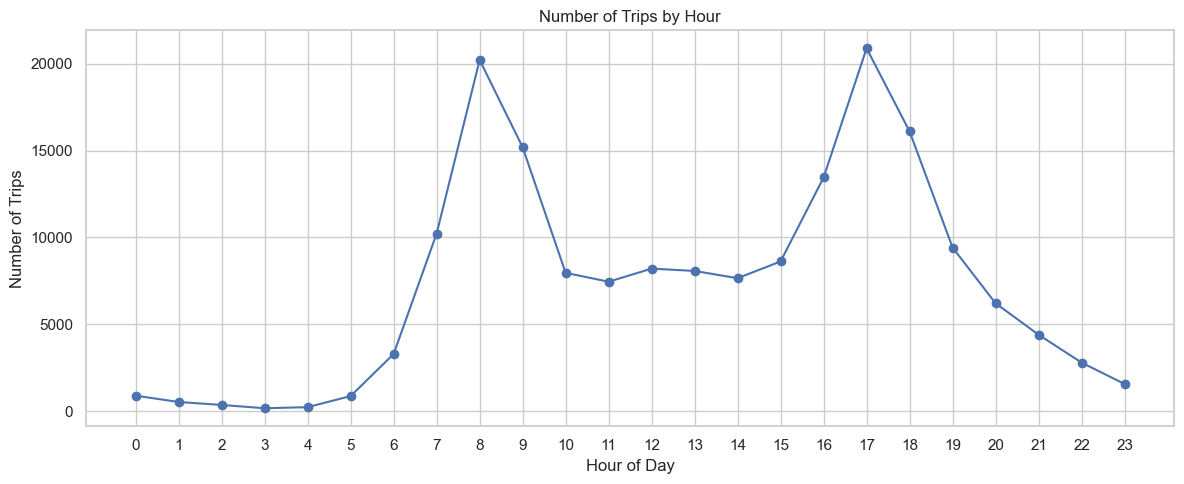

In [ ]:
#Trips by Hour

trips_by_hour = (
    df.groupby("start_hour")
      .size()
      .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(trips_by_hour.index, trips_by_hour.values, marker="o")

plt.title("Number of Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))
plt.tight_layout()
plt.show()
#Trip demand shows clear peaks around 8 AM and 5 PM.

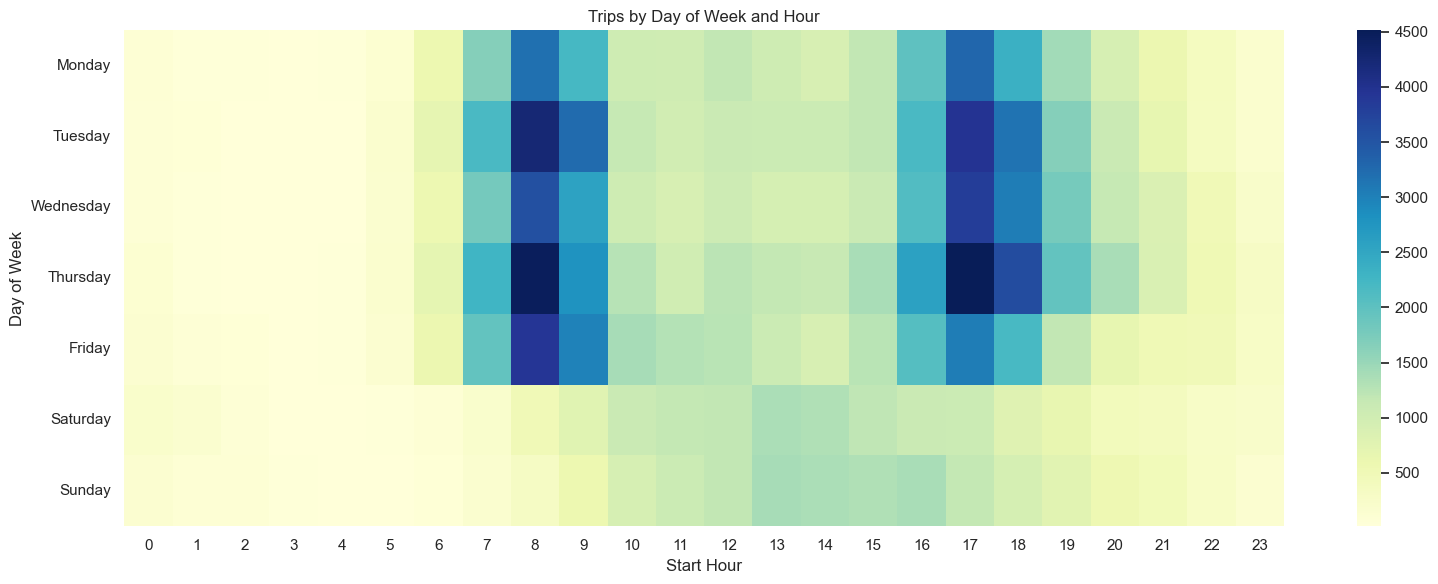

In [ ]:
#Day × Hour Heatmap
day_hour = (
    df.groupby(["day_name", "start_hour"])
      .size()
      .unstack(fill_value=0)
      .reindex(day_order)
)

plt.figure(figsize=(16, 6))
sns.heatmap(day_hour, cmap="YlGnBu")

plt.title("Trips by Day of Week and Hour")
plt.xlabel("Start Hour")
plt.ylabel("Day of Week")
plt.tight_layout()
plt.show()
#Weekdays show stronger morning and evening peaks, while weekend usage is more distributed throughout the day.

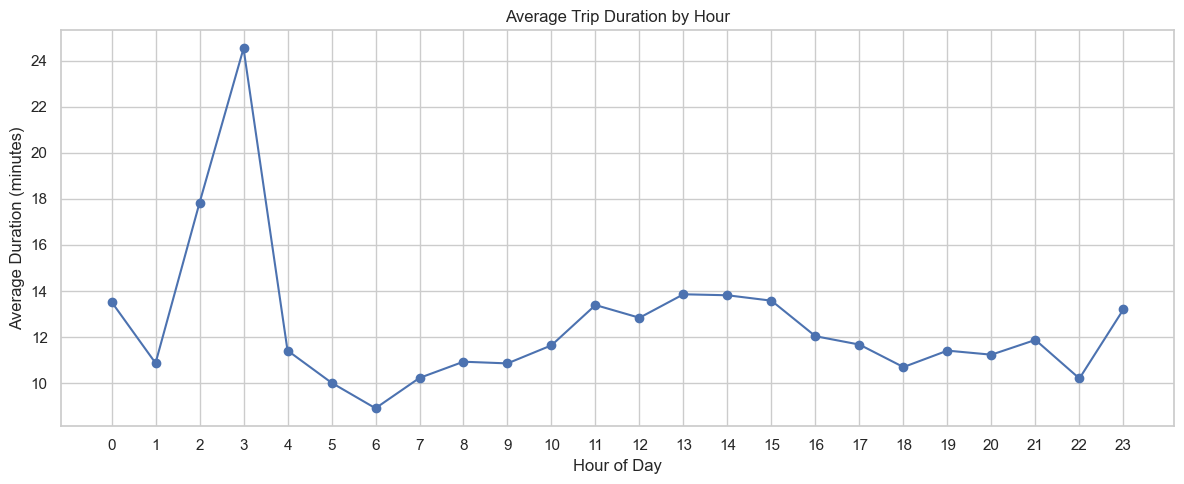

In [ ]:
# Average Duration by Hour
avg_duration_hour = (
    df.groupby("start_hour")["duration_min"]
      .mean()
      .sort_index()
)

plt.figure(figsize=(12, 5))
plt.plot(
    avg_duration_hour.index,
    avg_duration_hour.values,
    marker="o"
)

plt.title("Average Trip Duration by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Duration (minutes)")
plt.xticks(range(24))
plt.tight_layout()
plt.show()
#Average trip duration is relatively stable during high-demand hours, while some low-demand hours show higher averages.

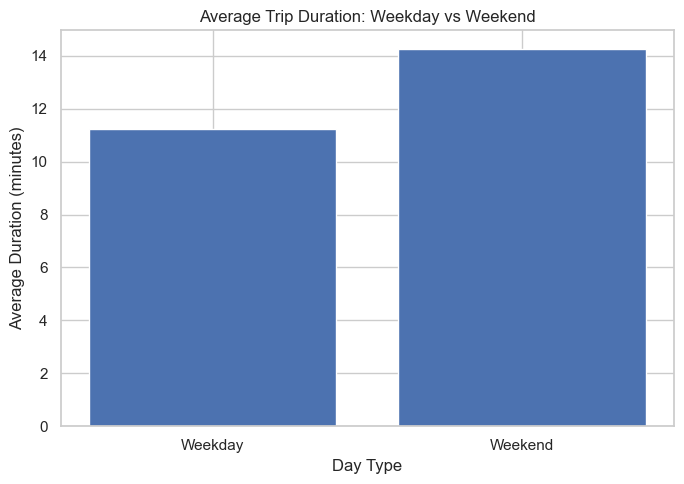

In [50]:
#Weekday vs Weekend Duration
#Weekend trips have a higher average duration than weekday trips (14.25 vs 11.23 minutes).
weekend_duration = (
    df.groupby("weekend_flag")["duration_min"]
      .mean()
)

labels = ["Weekday", "Weekend"]

plt.figure(figsize=(7, 5))
plt.bar(labels, weekend_duration.values)

plt.title("Average Trip Duration: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Duration (minutes)")
plt.tight_layout()
plt.show()

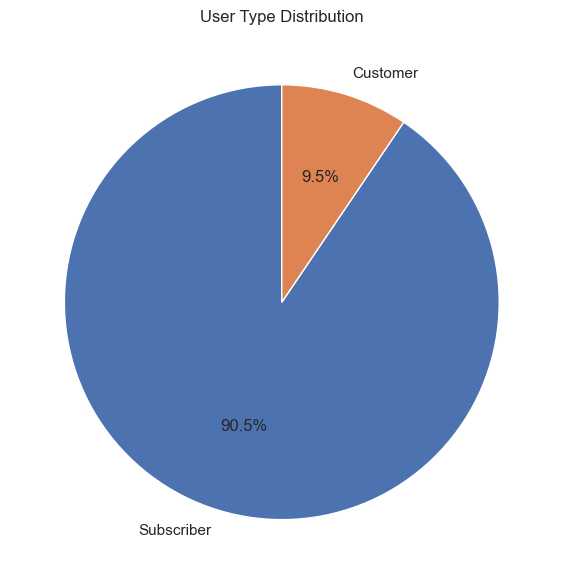

In [51]:
#User Type Distribution
#Subscribers account for the vast majority of trips.
user_counts = df["user_type"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    user_counts.values,
    labels=user_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("User Type Distribution")
plt.tight_layout()
plt.show()

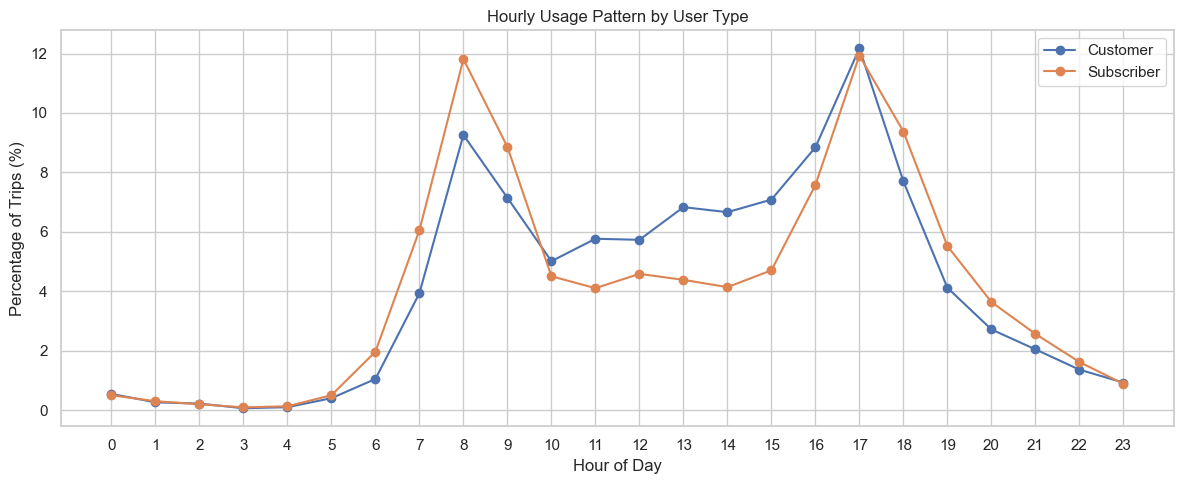

In [52]:
#User Type × Hour
#Both user types peak around 5 PM, while Subscribers show a stronger morning peak.
user_hour_pct = pd.crosstab(
    df["start_hour"],
    df["user_type"],
    normalize="columns"
) * 100

plt.figure(figsize=(12, 5))

plt.plot(
    user_hour_pct.index,
    user_hour_pct["Customer"],
    marker="o",
    label="Customer"
)

plt.plot(
    user_hour_pct.index,
    user_hour_pct["Subscriber"],
    marker="o",
    label="Subscriber"
)

plt.title("Hourly Usage Pattern by User Type")
plt.xlabel("Hour of Day")
plt.ylabel("Percentage of Trips (%)")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

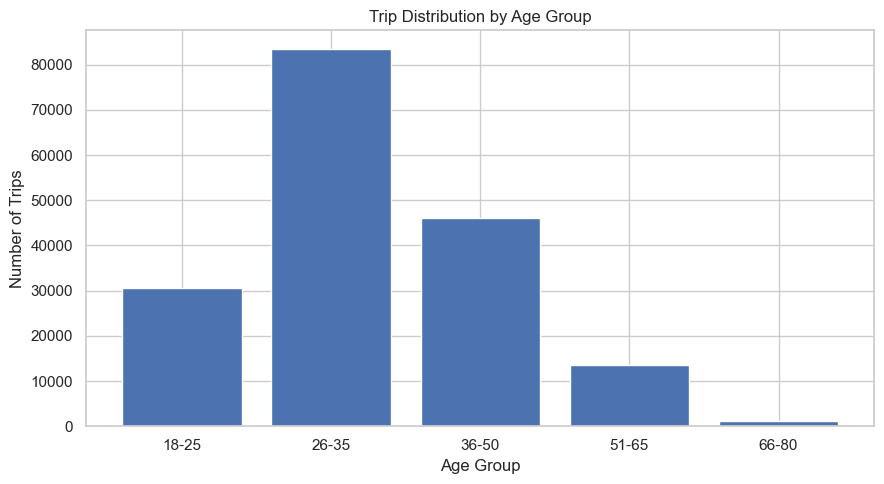

In [53]:
#Age Group Distribution
#Users aged 26–35 represent the largest age group in the dataset.
age_counts = df["age_group"].value_counts()

age_order = ["18-25", "26-35", "36-50", "51-65", "66-80"]

age_counts = age_counts.reindex(age_order)

plt.figure(figsize=(9, 5))
plt.bar(age_counts.index, age_counts.values)

plt.title("Trip Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

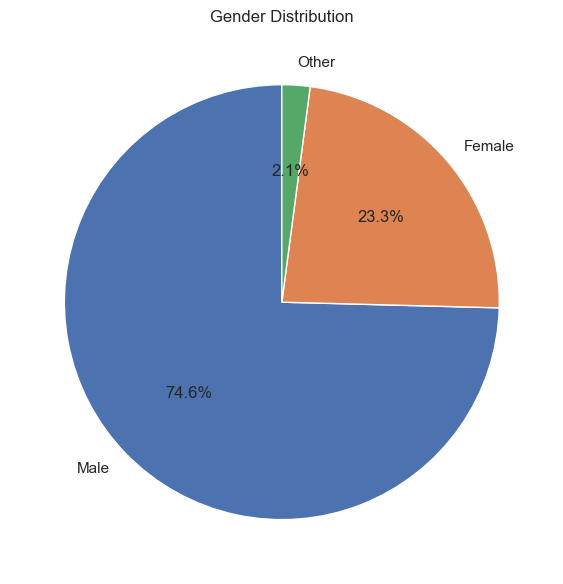

In [54]:
#Gender Distribution
#Male users account for the majority of trips.
gender_counts = df["member_gender"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

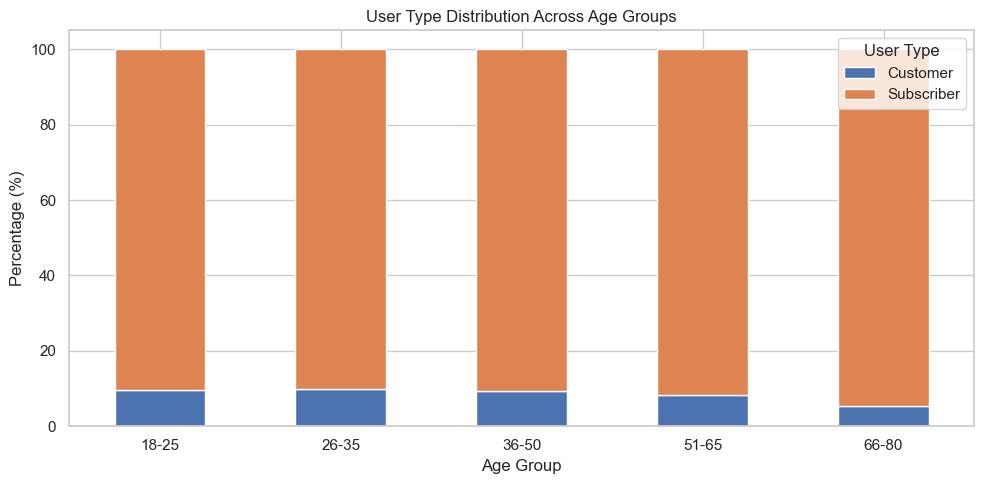

In [ ]:
#User Type × Age Group
#Both Customers and Subscribers show a similar age-group distribution, with the 26–35 group being dominant.
user_age_pct = pd.crosstab(
    df["age_group"],
    df["user_type"],
    normalize="index"
) * 100

user_age_pct = user_age_pct.reindex(age_order)

user_age_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.title("User Type Distribution Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="User Type")
plt.tight_layout()
plt.show()

In [1]:
from pathlib import Path

print(Path.cwd())

c:\DiskD\AI\Depi-Projects-AI-upload\Data-Analysis\ford_gobike_analysis\eda\notebooks
